# 🏔️ Análisis Topográfico de Aptitud Agroecológica (DEM + UPRA)

**Objetivo**: Analizar los patrones de altitud y pendiente (variables extraídas del Modelo Digital de Elevación) que caracterizan la aptitud de los diferentes cultivos estratégicos del Valle del Cauca.

In [1]:
# Importaciones necesarias
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo visual
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

BASE_DIR = Path('.').resolve().parent
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
REPORTS_DIR = BASE_DIR / 'data' / 'reports'

print('Librerías cargadas.')

Librerías cargadas.


## 1. Carga de Datos Consolidados
Vamos a leer todos los archivos GeoJSON enriquecidos con el DEM. Para acelerar el análisis estadístico, extraeremos únicamente los datos tabulares (ignorando la geometría temporalmente) y unificaremos todos los cultivos en un solo *DataFrame*.

In [2]:
archivos = glob.glob(str(PROCESSED_DIR / 'zonificacion_*_valle_con_dem.geojson'))
lista_df = []

print("Cargando archivos espaciales...")
for archivo in archivos:
    cultivo = Path(archivo).name.split('zonificacion_')[-1].split('_valle')[0].replace('_', ' ').title()
    # Leemos el GeoJSON con GeoPandas
    gdf = gpd.read_file(archivo)
    
    # Convertimos a Pandas DataFrame normal quitando la geometría por velocidad y memoria
    df = pd.DataFrame(gdf.drop(columns=['geometry']))
    df['cultivo'] = cultivo
    lista_df.append(df)

df_master = pd.concat(lista_df, ignore_index=True)
print(f"\n¡Carga completa! Total de registros analizados: {len(df_master):,}")
print(f"Cultivos incluidos: {', '.join(df_master['cultivo'].unique())}")

# Filtrar solo aptitudes de interés para no saturar gráficas
aptitudes_utiles = ['Aptitud alta', 'Aptitud media', 'Aptitud baja']
df_analisis = df_master[df_master['aptitud'].isin(aptitudes_utiles)].copy()

df_analisis.sample(5)

Cargando archivos espaciales...

¡Carga completa! Total de registros analizados: 45,226
Cultivos incluidos: Aguacate, Banano, Cacao, Cafe, Cana Panelera, Fresa, Papaya


,municipio,departamento,codigo_departamento,codigo_municipio,gridcode,area_ha,aptitud,consecutivo,:id,:version,:created_at,:updated_at,altitud_msnm,pendiente_grados,cultivo
33726,Yotoco,Valle del Cauca,76,76890,3,177.086166,Aptitud alta,122599,row-paap_pqw7~zcww,rv-atbb_237j~jm57,2021-04-23 23:34:54.154000+00:00,2021-04-23 23:34:54.154000+00:00,1386.0,20.533396,Cana Panelera
41506,Jamundí,Valle del Cauca,76,76364,2,0.057402,Aptitud media,114956,row-66np-f6gj.hrqm,rv-dd3m~cz2r-usha,2020-11-29 15:55:15.826000+00:00,2020-11-29 15:55:15.826000+00:00,1388.0,14.649694,Papaya
25474,Sevilla,Valle del Cauca,76,76736,3,0.600468,Aptitud alta,429356,row-5nt4~3w24~6mra,rv-r2i5-eykj-kqdm,2022-08-11 16:44:26.021000+00:00,2022-08-11 16:44:26.021000+00:00,1828.0,17.185583,Cafe
18136,Dagua,Valle del Cauca,76,76233,1,0.043215,Aptitud baja,127178,row-bs6e_pi7u_azt9,rv-pqec_j6br-7frs,2022-08-11 16:44:26.021000+00:00,2022-08-11 16:44:26.021000+00:00,1270.0,5.623872,Cafe
16872,Caicedonia,Valle del Cauca,76,76122,2,48.572281,Aptitud media,70171,row-gcms~8txy-kb7h,rv-2dai_9h9r.7ch3,2022-08-11 16:44:26.021000+00:00,2022-08-11 16:44:26.021000+00:00,1115.0,1.313362,Cafe


## 2. Análisis de Altitud (MSNM) por Cultivo
¿En qué rangos de altura sobre el nivel del mar se consideran "Aptos" los distintos cultivos en el Valle del Cauca?

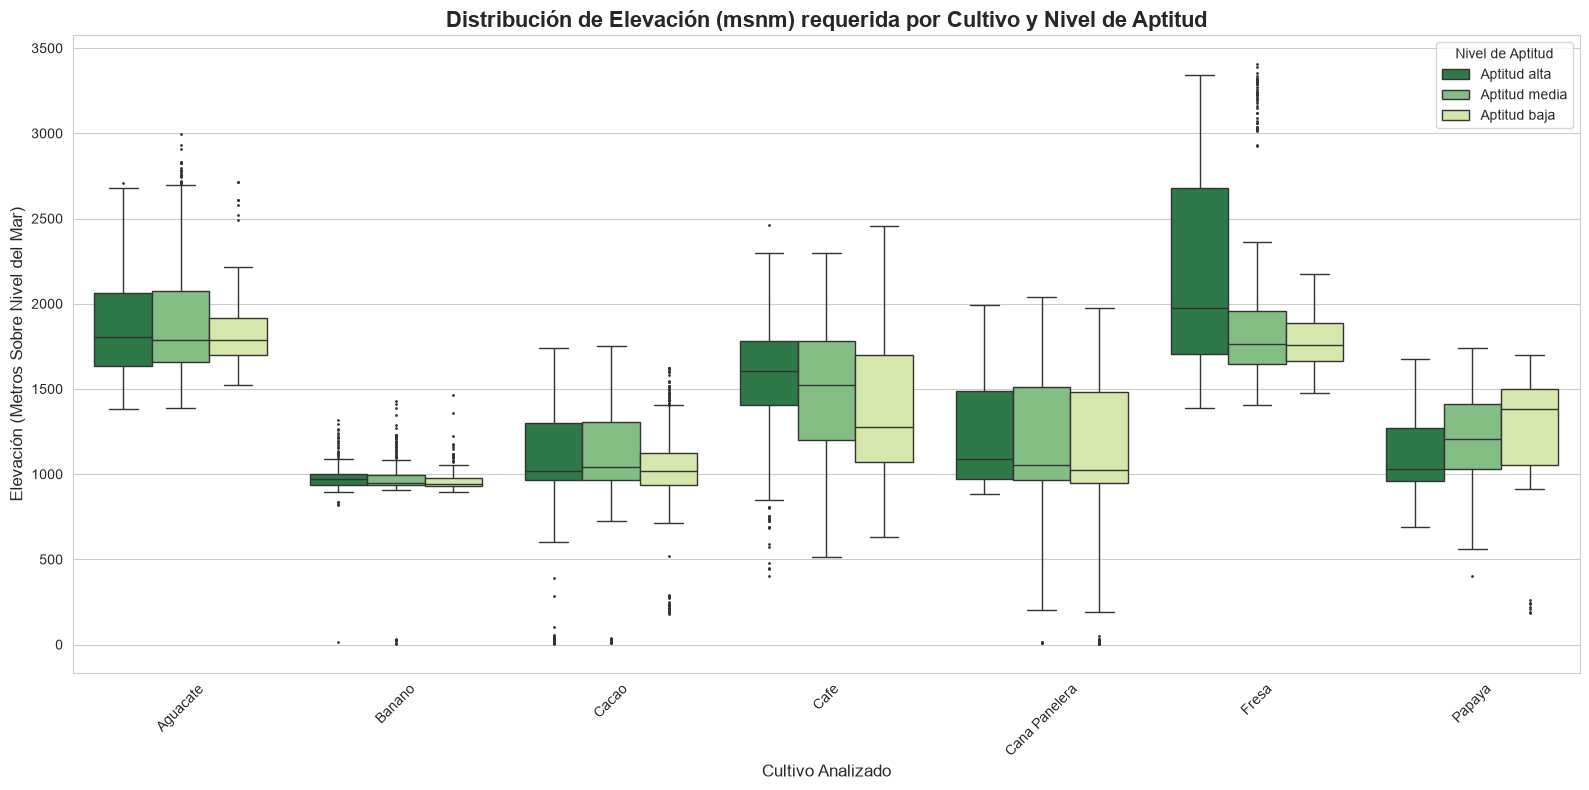

In [3]:
plt.figure(figsize=(16, 8))
orden_aptitud = ['Aptitud alta', 'Aptitud media', 'Aptitud baja']

sns.boxplot(data=df_analisis, x='cultivo', y='altitud_msnm', hue='aptitud', hue_order=orden_aptitud, palette='YlGn_r', fliersize=1)
plt.title('Distribución de Elevación (msnm) requerida por Cultivo y Nivel de Aptitud', fontsize=16, fontweight='bold')
plt.xlabel('Cultivo Analizado', fontsize=12)
plt.ylabel('Elevación (Metros Sobre Nivel del Mar)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Nivel de Aptitud')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig_altitud_por_cultivo.png', dpi=150)
plt.show()

### 💡 Insights de Elevación:
- El **Café** probablemente se agrupa en zonas altas y laderas (ej. 1,200 - 1,800 msnm).
- La **Caña Panelera** y el **Banano** tienen distribuciones muy distintas.
- Las zonas con *Aptitud Alta* son bandas de elevación muy bien delimitadas por la UPRA.

## 3. Análisis de Pendiente Topográfica (Grados)
La pendiente determina qué tan mecanizable es el terreno y la escorrentía del agua. ¿Cuáles cultivos requieren terrenos más planos?

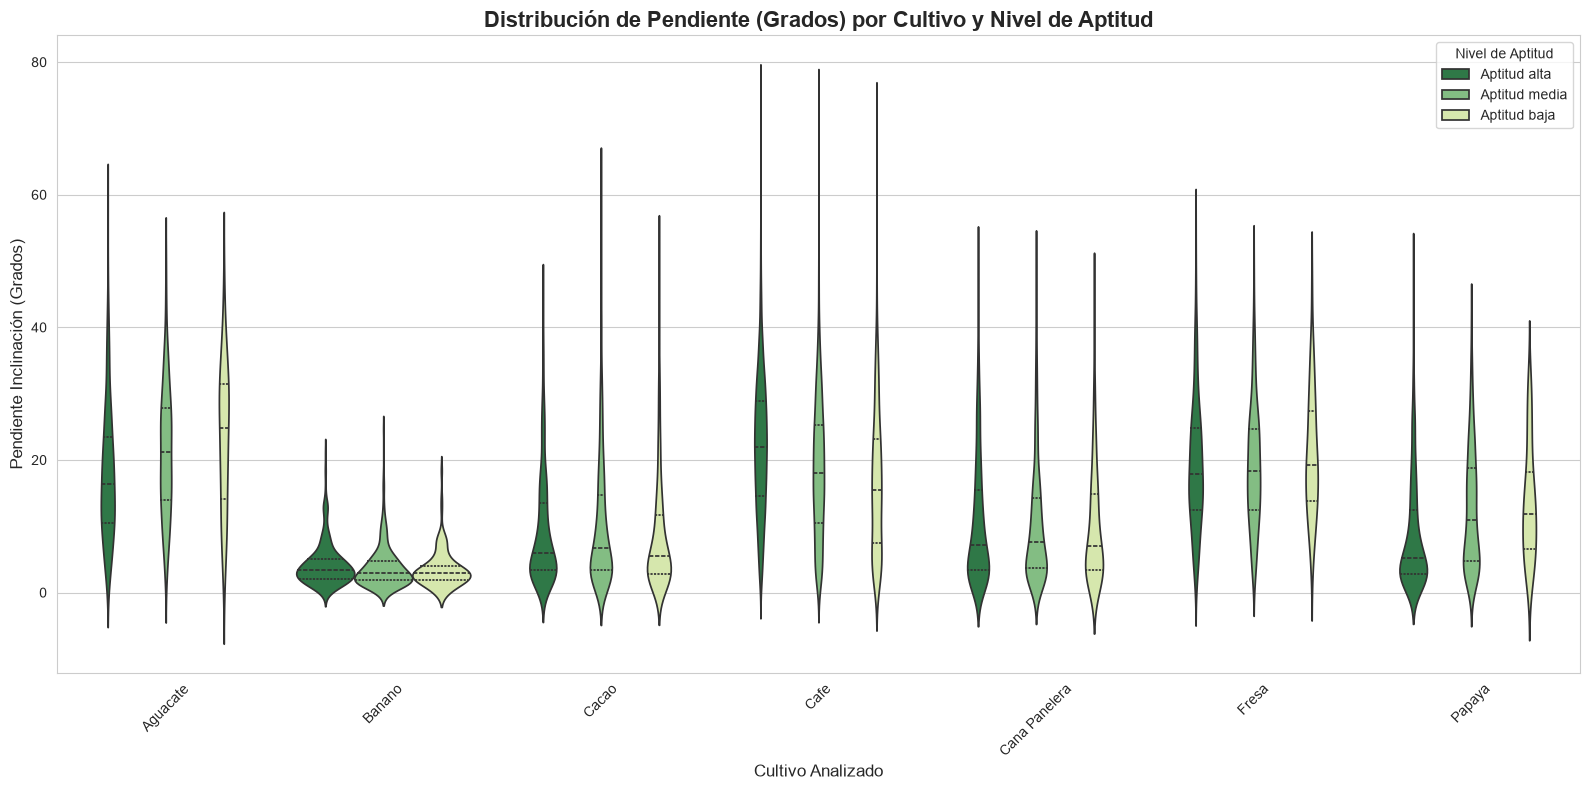

In [4]:
plt.figure(figsize=(16, 8))
sns.violinplot(data=df_analisis, x='cultivo', y='pendiente_grados', hue='aptitud', hue_order=orden_aptitud, palette='YlGn_r', split=False, inner='quartile')
plt.title('Distribución de Pendiente (Grados) por Cultivo y Nivel de Aptitud', fontsize=16, fontweight='bold')
plt.xlabel('Cultivo Analizado', fontsize=12)
plt.ylabel('Pendiente Inclinación (Grados)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Nivel de Aptitud')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig_pendiente_por_cultivo.png', dpi=150)
plt.show()

## 4. Resumen Estadístico Oficial para Entrenamiento (RFRK)
Estas son las medias y desviaciones de altitud y pendiente. Estos parámetros serán vitales para establecer las reglas de entrenamiento o las métricas de correlación del modelo RFRK.

In [5]:
resumen_topo = df_analisis.groupby(['cultivo', 'aptitud'])[['altitud_msnm', 'pendiente_grados']].agg(['mean', 'std']).round(2)

print("Promedios de Altitud y Pendiente por Aptitud:")
display(resumen_topo)

Promedios de Altitud y Pendiente por Aptitud:


altitud_msnm         pendiente_grados       
                                    mean     std             mean    std
cultivo       aptitud                                                   
Aguacate      Aptitud alta       1875.62  312.61            17.77   9.90
              Aptitud baja       1847.65  256.74            23.44  10.75
              Aptitud media      1930.92  381.25            21.20   9.71
Banano        Aptitud alta        979.62   92.04             4.26   3.24
              Aptitud baja        978.37   91.93             3.54   2.82
              Aptitud media       965.94  161.91             3.77   3.17
Cacao         Aptitud alta       1109.26  293.86             9.31   8.36
              Aptitud baja       1031.42  270.49             8.34   8.01
              Aptitud media      1133.91  247.85            10.17   9.35
Cafe          Aptitud alta       1583.65  261.03            22.08  10.21
              Aptitud baja       1420.07  418.86            16.53  10.90
              Aptitud media      1504.34  338.90            18.44  10.13
Cana Panelera Aptitud alta       1227.44  302.90            10.55   9.45
              Aptitud baja       1075.13  500.20            10.29   9.16
              Aptitud media      1213.15  346.78            10.30   9.02
Fresa         Aptitud alta       2193.23  578.73            19.18   9.66
              Aptitud baja       1783.95  155.78            20.68   9.29
              Aptitud media      1901.15  451.99            19.03   9.19
Papaya        Aptitud alta       1125.41  209.65             8.56   8.15
              Aptitud baja       1231.89  397.45            13.59   8.62
              Aptitud media      1226.33  228.36            12.63   9.02